<a href="https://colab.research.google.com/github/Koks-creator/FaceGenerating/blob/main/DCGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download from Kaggle

In [ ]:
from google.colab import files
files.upload()  # wgraj kaggle.json

!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d jessicali9530/celeba-dataset
!unzip celeba-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: img_align_celeba/img_align_celeba/197604.jpg  
  inflating: img_align_celeba/img_align_celeba/197605.jpg  
  inflating: img_align_celeba/img_align_celeba/197606.jpg  
  inflating: img_align_celeba/img_align_celeba/197607.jpg  
  inflating: img_align_celeba/img_align_celeba/197608.jpg  
  inflating: img_align_celeba/img_align_celeba/197609.jpg  
  inflating: img_align_celeba/img_align_celeba/197610.jpg  
  inflating: img_align_celeba/img_align_celeba/197611.jpg  
  inflating: img_align_celeba/img_align_celeba/197612.jpg  
  inflating: img_align_celeba/img_align_celeba/197613.jpg  
  inflating: img_align_celeba/img_align_celeba/197614.jpg  
  inflating: img_align_celeba/img_align_celeba/197615.jpg  
  inflating: img_align_celeba/img_align_celeba/197616.jpg  
  inflating: img_align_celeba/img_align_celeba/197617.jpg  
  inflating: img_align_celeba/img_align_celeba/197618.jpg  
  inflating: img_align_celeba/img_align_celeba/19

# Download from gdown

In [ ]:
!gdown 0B7EVK8r0v71pZjFTYXZWM3FlRnM -O celeba.zip
!unzip /content/celeba.zip

Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM

but Gdown can't. Please check connections and permissions.
unzip:  cannot find or open /content/celeba.zip, /content/celeba.zip.zip or /content/celeba.zip.ZIP.


In [ ]:
import cv2
from google.colab.patches import cv2_imshow


img = cv2.imread("/content/img_align_celeba/179244.jpg")
print(img.shape)
cv2_imshow(img)

AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
from typing import Union, List, Tuple
from pathlib import Path
import csv
import os
import pathlib
from tensorflow.keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import drive

# Mount drive

In [ ]:
MAIN_DIR = "/content/img_align_celeba/img_align_celeba"
IMG_SIZE = 64       # scale to 64x64
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE
LATENT_DIM = 100
CHECKPOINT_PATH = "/content/drive/MyDrive/face_gan/"

In [ ]:
drive.mount('/content/drive')
CHECKPOINT_DIR = os.path.dirname(CHECKPOINT_PATH)

Mounted at /content/drive


# Prepare data

In [ ]:
def load_and_prepare(path: Union[str, Path]):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)

    # CelebA centres faces — we crop the centre instead of stretching
    img = tf.image.resize_with_crop_or_pad(img, 128, 128)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    img = (tf.cast(img, tf.float32) - 127.5) / 127.5
    return img



| Normalizacja | Zakres | Używana gdy |
|---|---|---|
| `/ 255.0` | `[0, 1]` | klasyczne CNN (klasyfikacja, detekcja) |
| `(x - 127.5) / 127.5` | `[-1, 1]` | GAN-y z `tanh` na wyjściu |

W naszym generatorze ostatnia warstwa ma `activation='tanh'`, a `tanh` produkuje wartości w zakresie `[-1, 1]`. Gdybyś użył `/ 255.0`, to:

- **prawdziwe obrazy** byłyby w `[0, 1]`
- **wygenerowane obrazy** byłyby w `[-1, 1]`

Dyskryminator porównuje te dwa źródła — gdyby miały różne zakresy, od razu widziałby różnicę **nie dlatego że obraz jest słabej jakości, tylko dlatego że liczby są w innej skali**. Trening by się posypał.

Krótko: normalizacja musi być **spójna z funkcją aktywacji generatora**. `tanh` → `[-1, 1]` → używasz `(x - 127.5) / 127.5`.

Gdybyś zamiast `tanh` dał `sigmoid` na końcu generatora, wtedy `/ 255.0` byłoby poprawne.

---


---

**Dlaczego `tanh` a nie `ReLU` na wyjściu generatora?**

`ReLU` urywa wszystko poniżej zera — produkuje wartości w `[0, +∞)`, więc piksele nigdy nie byłyby ujemne. To brzmi niegroźnie, ale w praktyce sieć traci połowę przestrzeni reprezentacji. `tanh` daje symetryczny zakres `[-1, 1]`, dzięki czemu:

- gradient płynie w **obu kierunkach** (ujemna wartość = "przyciemnij", dodatnia = "rozjaśnij")
- sieć uczy się subtelniejszych różnic w jasności i kolorze
- działa symetrycznie względem zera, co stabilizuje trening

Mówiąc obrazowo — `ReLU` to jak malowanie tylko jaśniejszymi odcieniami, `tanh` daje pełną paletę.

---

**Dlaczego brak walidacji?**

W klasycznym ML walidacja odpowiada na pytanie: *"czy model dobrze generalizuje na nowych danych?"*

W GAN-ie to pytanie... nie ma sensu, bo:

- Generator **nie klasyfikuje ani nie przewiduje** — on generuje. Nie ma "poprawnej odpowiedzi" do porównania
- Nie ma `val_loss` który mógłby spaść lub wzrosnąć — loss generatora i dyskryminatora to nie metryki jakości obrazu, tylko sygnał dla wzajemnej gry
- Overfitting rozumie się inaczej — generator który "zakuł" dataset po prostu odtwarza zdjęcia zamiast generować nowe (tzw. **mode collapse**), ale tego nie wykryjesz walidacją

Zamiast walidacji w GAN-ach używa się:

| Metoda | Co mierzy |
|---|---|
| **FID** (Fréchet Inception Distance) | podobieństwo rozkładu wygenerowanych obrazów do prawdziwych |
| **IS** (Inception Score) | różnorodność i jakość generowanych obrazów |
| **wizualna inspekcja** | po prostu patrzysz co generator produkuje co N epok |

W praktyce przy CelebA najczęściej co kilka epok zapisujesz siatkę wygenerowanych twarzy i oceniasz wzrokiem czy idzie w dobrą stronę.

---



In [ ]:
all_paths = tf.data.Dataset.list_files(f"{MAIN_DIR}/*.jpg", shuffle=True)

dataset = (
    all_paths
    .map(load_and_prepare, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(AUTOTUNE)
)

print(f"Batch count: {len(dataset)}")
sample = next(iter(dataset))
print(f"Batch size: {sample.shape}")   # (128, 64, 64, 3)
print(f"Min: {sample.numpy().min():.2f}, Max: {sample.numpy().max():.2f}")  # -1.0 do 1.0

Batch count: 1582
Batch size: (128, 64, 64, 3)
Min: -1.00, Max: 1.00


# Building model

In [ ]:
def build_generator(latent_dim=100):
    model = tf.keras.Sequential([
        layers.Dense(4 * 4 * 512, use_bias=False, input_shape=(latent_dim,)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Reshape((4, 4, 512)),

        layers.Conv2DTranspose(256, kernel_size=4, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.Conv2DTranspose(3, kernel_size=4, strides=2, padding='same',
                               use_bias=False, activation='tanh'),
    ], name="generator")
    return model

In [ ]:
def build_discriminator(img_shape=(64, 64, 3)):
    model = tf.keras.Sequential([
        layers.Conv2D(64, kernel_size=4, strides=2, padding='same', input_shape=img_shape),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Conv2D(128, kernel_size=4, strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Conv2D(256, kernel_size=4, strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1, activation='sigmoid'),
    ], name="discriminator")
    return model


In [ ]:
class DCGAN(tf.keras.Model):
    def __init__(self, generator, discriminator, latent_dim):
        super().__init__()
        self.generator     = generator
        self.discriminator = discriminator
        self.latent_dim    = latent_dim

    def compile(self, gen_optimizer, disc_optimizer, loss_fn):
        super().compile()
        self.gen_optimizer  = gen_optimizer
        self.disc_optimizer = disc_optimizer
        self.loss_fn        = loss_fn
        self.gen_loss_metric  = tf.keras.metrics.Mean(name="gen_loss")
        self.disc_loss_metric = tf.keras.metrics.Mean(name="disc_loss")

    @property
    def metrics(self):
        return [self.gen_loss_metric, self.disc_loss_metric]

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]

        # Generate random noise vectors — one per image in the batch
        # This is the generator's "seed" — different noise = different face
        # It's basically random float in array of shape (64, 100)
        noise = tf.random.normal([batch_size, self.latent_dim])

        # GradientTape records all operations inside the block
        # so it can compute gradients (how much to adjust each weight)
        # Two separate tapes — one per model, because they update independently
        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

            # Generator produces fake images from noise
            # training=True enables BatchNormalization and Dropout
            fake_images = self.generator(noise, training=True)

            # Discriminator evaluates both real and fake images
            # real_output — scores for images from the dataset
            # fake_output — scores for images produced by generator
            real_output = self.discriminator(real_images, training=True)
            fake_output = self.discriminator(fake_images, training=True)


            # Discriminator loss — it wants to:
            # - output 1.0 for real images (tf.ones_like)
            # - output 0.0 for fake images (tf.zeros_like)

            # Label smoothing — dyskryminator nigdy nie jest w 100% pewny
            real_labels = tf.ones_like(real_output) * 0.9   # ← zamiast ones_like
            fake_labels = tf.zeros_like(fake_output)         # ← fake zostawiamy 0.0

            # ones_like - converts every value in array to 1
            # zeros_like - converts every value in array to 0
            # disc_loss = (
            #     self.loss_fn(tf.ones_like(real_output),  real_output) +
            #     self.loss_fn(tf.zeros_like(fake_output), fake_output)
            # )

            disc_loss = (
                self.loss_fn(real_labels, real_output) +
                self.loss_fn(fake_labels, fake_output)
            )

            """
            self.loss_fn(tf.ones_like(real_output),  real_output)
            +
            self.loss_fn(tf.zeros_like(fake_output), fake_output)

            # Real images — the classifier should output 1.0
            ones_like  = [[1.0], [1.0], [1.0], [1.0]]  # expected
            real_output = [[0.9], [0.3], [0.8], [0.6]]  # actual scores

            # loss is high for 0.3 (it was very wrong)
            # loss is low for 0.9 (it was almost right)

            # Fake images — the discriminator should say 0.0
            zeros_like  = [[0.0], [0.0], [0.0], [0.0]]  # expected
            fake_output = [[0.1], [0.7], [0.2], [0.4]]  # actual scores

            # loss is high for 0.7 (it was fooled by the generator)
            # loss is small for 0.1 (it correctly detected the fake image)

            we sum it up, because discriminator has 2 tasks - recognizing real images as real
            and fake ones as fake
            """

            # Generator loss — it wants discriminator to output 1.0 for fake images
            # i.e. fool the discriminator into thinking fakes are real
            gen_loss = self.loss_fn(tf.ones_like(fake_output), fake_output)

        # Compute gradients — how much should each weight change
        # each model only updates its own weights, not the other's
        gen_grads  = gen_tape.gradient(gen_loss,  self.generator.trainable_variables)
        disc_grads = disc_tape.gradient(disc_loss, self.discriminator.trainable_variables)

        # Apply gradients — actually update the weights
        self.gen_optimizer.apply_gradients(zip(gen_grads,  self.generator.trainable_variables))
        self.disc_optimizer.apply_gradients(zip(disc_grads, self.discriminator.trainable_variables))

        # Update metrics visible in model.fit progress bar
        self.gen_loss_metric.update_state(gen_loss)
        self.disc_loss_metric.update_state(disc_loss)

        return {m.name: m.result() for m in self.metrics}

In [ ]:
class ImageSampleCallback(tf.keras.callbacks.Callback):
    def __init__(self, latent_dim, n=16):
        self.seed = tf.random.normal([n, latent_dim])

    def on_epoch_end(self, epoch, logs=None):
        if epoch > 0 and epoch % 10 == 0:
            generated = self.model.generator(self.seed, training=False)
            generated = (generated + 1.0) / 2.0  # [-1,1] → [0,1] do wyświetlenia

            fig, axes = plt.subplots(4, 4, figsize=(8, 8))
            for i, ax in enumerate(axes.flat):
                ax.imshow(generated[i].numpy())
                ax.axis('off')
            plt.suptitle(f"Epoch {epoch + 1}")
            plt.tight_layout()
            plt.show()

class CustomCSVLogger(tf.keras.callbacks.Callback):
    def __init__(self, log_path):
        super().__init__()
        self.log_path = log_path
        # self.epoch = 0

    def on_train_begin(self, logs=None):
        self.csvfile = open(self.log_path, "w", newline='')
        self.writer = csv.writer(self.csvfile)
        self.writer.writerow(["epoch", "disc_loss", "gen_loss"])
        self.csvfile.flush()
        self.csvfile.close()

    def on_epoch_end(self, epoch: int, logs=None):
        self.csvfile = open(self.log_path, "a", newline="")
        self.writer = csv.writer(self.csvfile)
        logs = logs or {}

        row = [
            epoch,
            logs.get("disc_loss", "N/A"),
            logs.get("gen_loss", "N/A"),
        ]
        self.writer.writerow(row)
        self.csvfile.flush()
        self.csvfile.close()

    def on_train_end(self, logs=None) -> None:
        self.csvfile.close()

class SaveCheckpointCallback(tf.keras.callbacks.Callback):
    def __init__(self, save_dir):
          super().__init__()
          self.save_dir = save_dir
    def on_epoch_end(self, epoch, logs=None):
        self.model.generator.save_weights(f"{self.save_dir}/generator_dcgan_epoch_{epoch+1}.weights.h5")
        self.model.discriminator.save_weights(f"{self.save_dir}/discriminator_dcgan_epoch_{epoch+1}.weights.h5")
        print(f"\nSaving checkpoint — epoch {epoch+1}")

# Training

In [ ]:
CHECKPOINT_EPOCH = 0

if CHECKPOINT_EPOCH:
    print("Loading from checkpiont")
    print(f"{CHECKPOINT_DIR}/generator_dcgan_epoch_{CHECKPOINT_EPOCH}.weights.h5")
    print(f"{CHECKPOINT_DIR}/discriminator_dcgan_epoch_{CHECKPOINT_EPOCH}.weights.h5")

    generator = build_generator(LATENT_DIM)
    discriminator = build_discriminator()

    # Dummy forward pass
    generator(tf.random.normal([1, LATENT_DIM]))
    discriminator(tf.random.normal([1, 64, 64, 3]))

    generator.load_weights(f"{CHECKPOINT_DIR}/generator_dcgan_epoch_{CHECKPOINT_EPOCH}.weights.h5")
    discriminator.load_weights(f"{CHECKPOINT_DIR}/discriminator_dcgan_epoch_{CHECKPOINT_EPOCH}.weights.h5")
else:
    print("loading fresh model")
    generator = build_generator(LATENT_DIM)
    discriminator = build_discriminator()

gan = DCGAN(
    generator=generator,
    discriminator=discriminator,
    latent_dim=LATENT_DIM
)

gan.compile(
    gen_optimizer = tf.keras.optimizers.Adam(5e-5, beta_1=0.0, beta_2=0.9),
    disc_optimizer = tf.keras.optimizers.Adam(5e-5, beta_1=0.0, beta_2=0.9),
    loss_fn=tf.keras.losses.BinaryCrossentropy()
)


Loading from checkpiont
/content/drive/MyDrive/face_gan/generator_dcgan_epoch_24.weights.h5
/content/drive/MyDrive/face_gan/discriminator_dcgan_epoch_24.weights.h5


In [ ]:
gan.fit(
    dataset,
    epochs=50,
    initial_epoch=CHECKPOINT_EPOCH,
    callbacks=[
        CustomCSVLogger(f"{CHECKPOINT_DIR}/training_dcgan_log.csv"),
        SaveCheckpointCallback(save_dir=CHECKPOINT_DIR)
    ]
)

Epoch 25/50
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - disc_loss: 0.7905 - gen_loss: 2.4909
Saving checkpoint — epoch 25
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 154s 88ms/step - disc_loss: 0.7868 - gen_loss: 2.5038
Epoch 26/50
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - disc_loss: 0.7805 - gen_loss: 2.5541
Saving checkpoint — epoch 26
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 138s 87ms/step - disc_loss: 0.7831 - gen_loss: 2.5596
Epoch 27/50
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - disc_loss: 0.7728 - gen_loss: 2.5893
Saving checkpoint — epoch 27
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 139s 88ms/step - disc_loss: 0.7694 - gen_loss: 2.6114
Epoch 28/50
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - disc_loss: 0.7694 - gen_loss: 2.6582
Saving checkpoint — epoch 28
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 139s 88ms/step - disc_loss: 0.7600 - gen_loss: 2.6757
Epoch 29/50
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - disc_loss: 0.7574 - gen_loss: 2.6808
Saving checkpoint — epoch 29
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 142s 88ms

# Save mdoel

In [ ]:
gan.generator.save(f"{CHECKPOINT_DIR}/generator_dcgan_1.h5")
gan.discriminator.save(f"{CHECKPOINT_DIR}/discriminator_dcgan_1.h5")

# Test

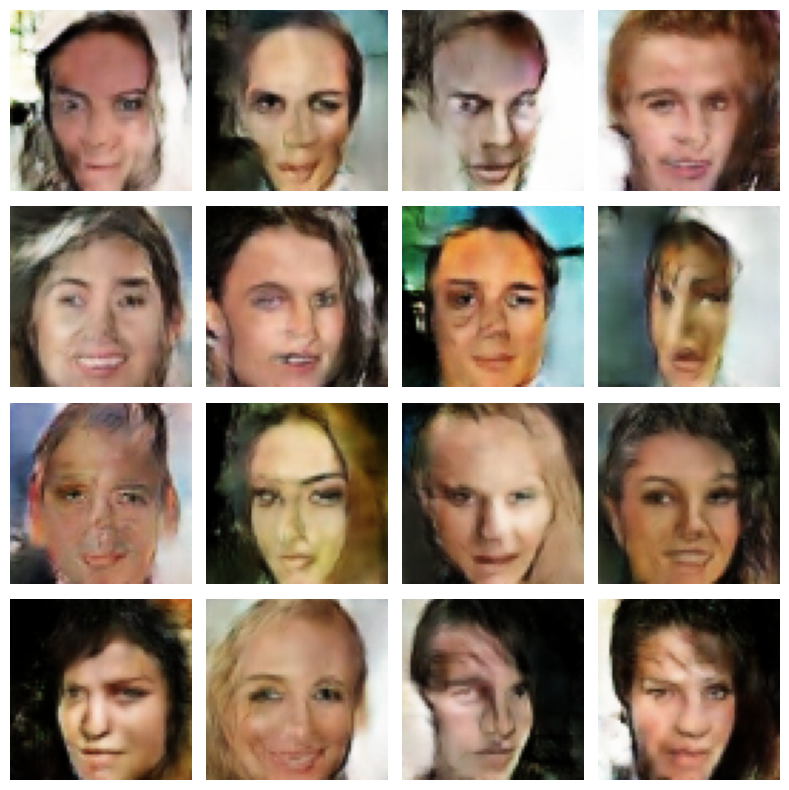

In [ ]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt


gan.generator.save("generator_dcgan.h5")
gan.discriminator.save("discriminator_dcgan.h5")

generator = load_model("generator_dcgan.h5")
discriminator = load_model("discriminator_dcgan.h5")


def generate_faces(generator, n=16):
    noise = tf.random.normal([n, 100])
    generated = generator(noise, training=False)
    generated = (generated + 1.0) / 2.0  # [-1,1] → [0,1]

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated[i].numpy())
        ax.axis('off')
    plt.tight_layout()
    plt.show()

generate_faces(generator)